In [1]:
import json
import pandas as pd

# Load JSON data
with open('3Site/new_traces.json') as f:
    data = json.load(f)

results = []

# Process each trace
for trace in data['data']:
    trace_id = trace['traceID']
    spans = trace['spans']

    # Check there are at least 7 spans to access indices 0 and 6
    if len(spans) >= 7:
        span1_us = spans[0]['duration']   # duration in microseconds
        span6_us = spans[6]['duration']
        total_us = span1_us + span6_us

        # Convert durations from microseconds to milliseconds
        results.append({
            'traceID': trace_id,
            'trigger_ms': span1_us / 1000,
            'dispatcher_ms': span6_us / 1000,
            'total_duration_ms': total_us / 1000
        })

# Create a pandas DataFrame from the results
df = pd.DataFrame(results)

# Print the DataFrame
df.head(15)


,traceID,trigger_ms,dispatcher_ms,total_duration_ms
0,ef8dc539b86c2afbb4d8f8e28c21fe07,3.866,1376.293,1380.159
1,4987d9295103e8d7f745f88cea4a53af,2.391,1449.871,1452.262
2,fe66cb6fb2e8f91eeb4b5f0e60bbae22,1.564,1004.257,1005.821
3,006816f9a68ff5348c1f1f714c6a34e5,2.021,1018.789,1020.810
4,9cfcb96b75f091d1b2bf7392b63557dc,1.954,1000.054,1002.008
5,3ace7e51aef3d923990f4a043610ba7d,3.101,1023.963,1027.064
6,885bc56c2294d340f5fb25630e7aefec,1.793,1418.415,1420.208
7,64ef030cbd683e591d1ddd059db6e34f,2.005,2.920,4.925
8,087b28d3ce5b542b83b75eff4994f9e1,1.825,5.832,7.657
9,b6d699367efa4753254dc8b0544958e4,2.868,3.593,6.461


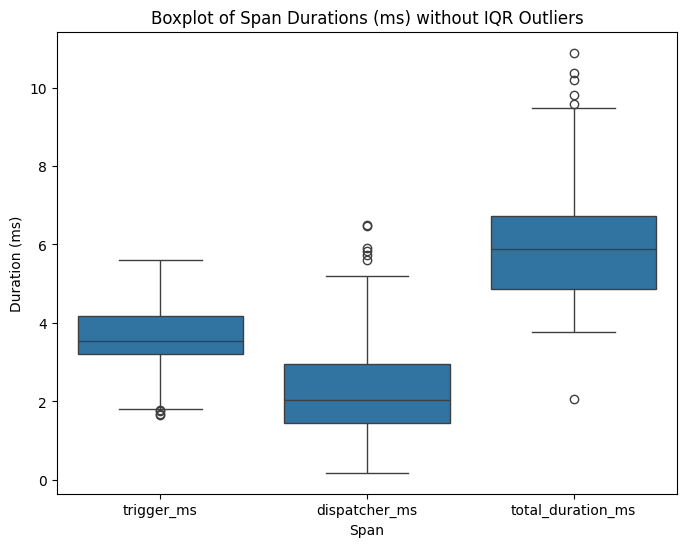

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Remove outliers for each duration column independently
df_filtered_trigger = remove_outliers_iqr(df, 'trigger_ms')
df_filtered_dispatcher = remove_outliers_iqr(df, 'dispatcher_ms')
df_filtered_total = remove_outliers_iqr(df, 'total_duration_ms')

# Keep rows that are inside IQR range for all three columns
df_filtered = df[
    df.index.isin(df_filtered_trigger.index) & 
    df.index.isin(df_filtered_dispatcher.index) & 
    df.index.isin(df_filtered_total.index)
]

# Melt filtered data for seaborn
df_melted = df_filtered.melt(
    id_vars='traceID',
    value_vars=['trigger_ms', 'dispatcher_ms', 'total_duration_ms'],
    var_name='Span', value_name='Duration_ms'
)

plt.figure(figsize=(8,6))
sns.boxplot(x='Span', y='Duration_ms', data=df_melted)

plt.title('Boxplot of Span Durations (ms) without IQR Outliers')
plt.ylabel('Duration (ms)')
plt.xlabel('Span')
plt.show()


                              traceID  trigger_ms  dispatcher_ms
7    64ef030cbd683e591d1ddd059db6e34f       2.005          2.920
8    087b28d3ce5b542b83b75eff4994f9e1       1.825          5.832
9    b6d699367efa4753254dc8b0544958e4       2.868          3.593
11   3279b01f018e22ceed9db5b3b175ba69       1.775          3.019
12   42f6e6329bdf50763d1cc92d2a934fe9       2.665          1.464
..                                ...         ...            ...
195  4e63b5135db47e1988404f5af2450af5       4.178          2.390
196  9433a04bfe2ab9411404591adfe843f8       4.244          3.456
197  995247c3c4f7349d4b82eefb71b0dabe       4.134          1.913
198  e9aad4182a0ae591c6cedffa61279c83       3.916          1.772
199  627bf0b5eaa0216094f2f7e094f2c9b3       5.252          3.004

[161 rows x 3 columns]


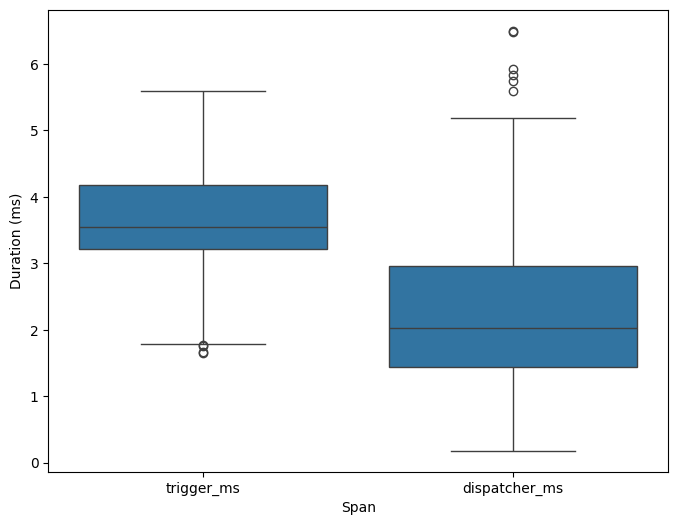

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Remove outliers for each duration column independently
df_filtered_trigger = remove_outliers_iqr(df, 'trigger_ms')
df_filtered_dispatcher = remove_outliers_iqr(df, 'dispatcher_ms')
df_filtered_total = remove_outliers_iqr(df, 'total_duration_ms')

# Keep rows that are inside IQR range for all three columns
df_filtered = df[
    df.index.isin(df_filtered_trigger.index) & 
    df.index.isin(df_filtered_dispatcher.index) & 
    df.index.isin(df_filtered_total.index)
]

# Extract only traceID, trigger_ms and dispatcher_ms columns
df_show = df_filtered[['traceID', 'trigger_ms', 'dispatcher_ms']]
print(df_show)

# Melt only the two columns for plotting
df_melted = df_filtered.melt(
    id_vars='traceID',
    value_vars=['trigger_ms', 'dispatcher_ms'],  # only two columns here
    var_name='Span', value_name='Duration_ms'
)

plt.figure(figsize=(8,6))
sns.boxplot(x='Span', y='Duration_ms', data=df_melted)

plt.ylabel('Duration (ms)')
plt.xlabel('Span')
plt.savefig('Boxplot of Span Durations (ms) Clipped at 95th Percentile NoBalancing')
plt.show()


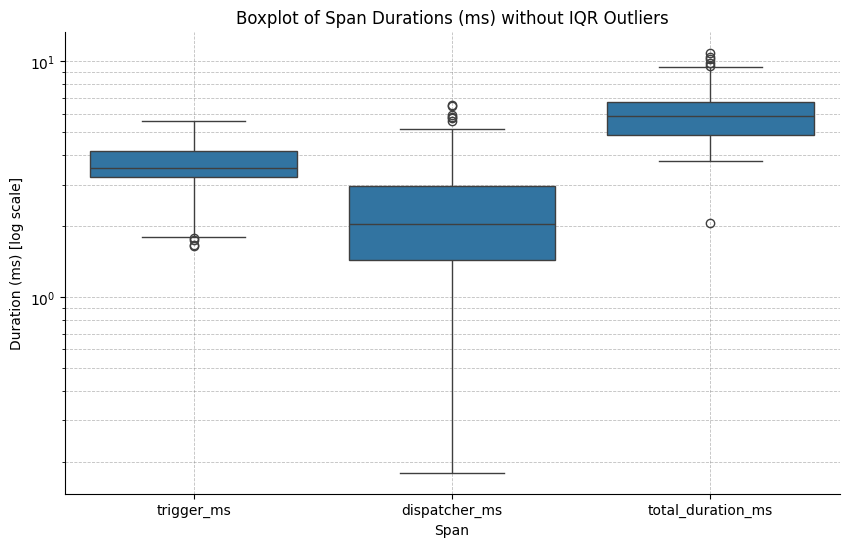

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Example: Assuming df is your original DataFrame with these columns:
# df = pd.read_csv('your_data.csv')  # or however you load your data

# Remove outliers for each duration column independently
df_filtered_trigger = remove_outliers_iqr(df, 'trigger_ms')
df_filtered_dispatcher = remove_outliers_iqr(df, 'dispatcher_ms')
df_filtered_total = remove_outliers_iqr(df, 'total_duration_ms')

# Keep rows that are inside IQR range for all three columns
df_filtered = df[
    df.index.isin(df_filtered_trigger.index) & 
    df.index.isin(df_filtered_dispatcher.index) & 
    df.index.isin(df_filtered_total.index)
]

# Melt filtered data for seaborn
df_melted = df_filtered.melt(
    id_vars='traceID',
    value_vars=['trigger_ms', 'dispatcher_ms', 'total_duration_ms'],
    var_name='Span', value_name='Duration_ms'
)

plt.figure(figsize=(10,6))
sns.boxplot(x='Span', y='Duration_ms', data=df_melted)

plt.yscale('log')  # Apply log scale to y-axis

plt.title('Boxplot of Span Durations (ms) without IQR Outliers')
plt.ylabel('Duration (ms) [log scale]')
plt.xlabel('Span')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, color='gray', alpha=0.5)

sns.despine()
plt.show()


                              traceID  trigger_ms  dispatcher_ms
7    64ef030cbd683e591d1ddd059db6e34f       2.005          2.920
8    087b28d3ce5b542b83b75eff4994f9e1       1.825          5.832
9    b6d699367efa4753254dc8b0544958e4       2.868          3.593
11   3279b01f018e22ceed9db5b3b175ba69       1.775          3.019
12   42f6e6329bdf50763d1cc92d2a934fe9       2.665          1.464
..                                ...         ...            ...
195  4e63b5135db47e1988404f5af2450af5       4.178          2.390
196  9433a04bfe2ab9411404591adfe843f8       4.244          3.456
197  995247c3c4f7349d4b82eefb71b0dabe       4.134          1.913
198  e9aad4182a0ae591c6cedffa61279c83       3.916          1.772
199  627bf0b5eaa0216094f2f7e094f2c9b3       5.252          3.004

[161 rows x 3 columns]


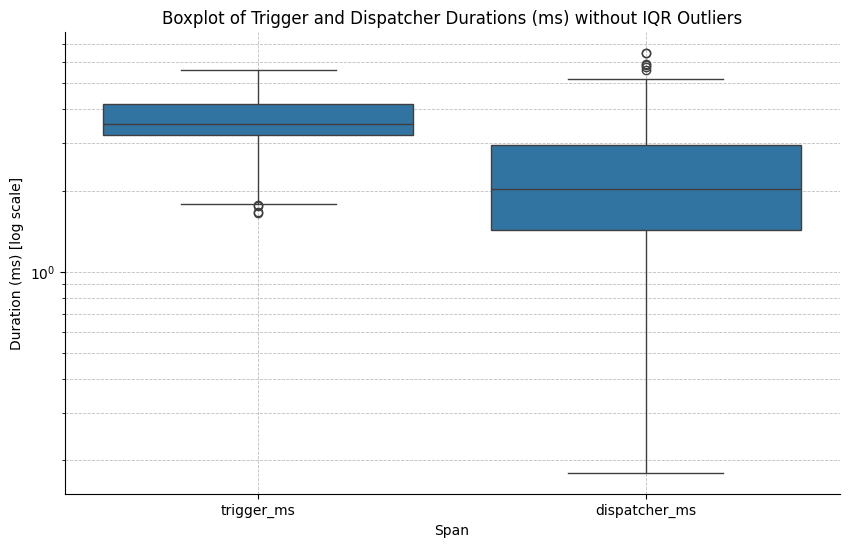

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Remove outliers for each duration column independently
df_filtered_trigger = remove_outliers_iqr(df, 'trigger_ms')
df_filtered_dispatcher = remove_outliers_iqr(df, 'dispatcher_ms')
df_filtered_total = remove_outliers_iqr(df, 'total_duration_ms')

# Keep rows inside IQR for all three columns
df_filtered = df[
    df.index.isin(df_filtered_trigger.index) & 
    df.index.isin(df_filtered_dispatcher.index) & 
    df.index.isin(df_filtered_total.index)
]

# Extract only traceID, trigger_ms, and dispatcher_ms for display (optional)
df_show = df_filtered[['traceID', 'trigger_ms', 'dispatcher_ms']]
print(df_show)

# Melt only trigger_ms and dispatcher_ms for plotting
df_melted = df_filtered.melt(
    id_vars='traceID',
    value_vars=['trigger_ms', 'dispatcher_ms'],
    var_name='Span', value_name='Duration_ms'
)

plt.figure(figsize=(10,6))
sns.boxplot(x='Span', y='Duration_ms', data=df_melted)

plt.yscale('log')  # log scale on y-axis
plt.title('Boxplot of Trigger and Dispatcher Durations (ms) without IQR Outliers')
plt.ylabel('Duration (ms) [log scale]')
plt.xlabel('Span')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, color='gray', alpha=0.5)
sns.despine()
plt.show()
